In [1]:
# Alle Dateien in Array-Koordinaten umbenennen

import os
import re

# Ordner auswählen
folder = r"./Cut Folder (Complete)"   # <--- HIER deinen Ordnerpfad eintragen

# Regex zum Finden der letzten 3 Ziffern
pattern = re.compile(r"(.*?)(\d{3})$")

for filename in os.listdir(folder):
    name, ext = os.path.splitext(filename)

    match = pattern.match(name)
    if not match:
        print(f"Übersprungen (passt nicht): {filename}")
        continue

    base, num_str = match.groups()
    num = int(num_str) - 1 # "001" → 0, "023" → 22 usw.

    # Neue Werte berechnen
    x = (num % 11) + 1
    y = (num // 11) + 1

    # x zweistellig
    x_str = f"{x:02d}"

    # Neues Suffix
    new_suffix = f"{y}_{x_str}"

    # Neuer Dateiname
    new_name = f"{base}{new_suffix}{ext}"

    old_path = os.path.join(folder, filename)
    new_path = os.path.join(folder, new_name)

    os.rename(old_path, new_path)

    print(f"Umbenannt: {filename}  →  {new_name}")


Umbenannt: 1_1_1_001.wav  →  1_1_1_1_01.wav
Umbenannt: 1_1_1_002.wav  →  1_1_1_1_02.wav
Umbenannt: 1_1_1_003.wav  →  1_1_1_1_03.wav
Umbenannt: 1_1_1_004.wav  →  1_1_1_1_04.wav
Umbenannt: 1_1_1_005.wav  →  1_1_1_1_05.wav
Umbenannt: 1_1_1_006.wav  →  1_1_1_1_06.wav
Umbenannt: 1_1_1_007.wav  →  1_1_1_1_07.wav
Umbenannt: 1_1_1_008.wav  →  1_1_1_1_08.wav
Umbenannt: 1_1_1_009.wav  →  1_1_1_1_09.wav
Umbenannt: 1_1_1_010.wav  →  1_1_1_1_10.wav
Umbenannt: 1_1_1_011.wav  →  1_1_1_1_11.wav
Umbenannt: 1_1_1_012.wav  →  1_1_1_2_01.wav
Umbenannt: 1_1_1_013.wav  →  1_1_1_2_02.wav
Umbenannt: 1_1_1_014.wav  →  1_1_1_2_03.wav
Umbenannt: 1_1_1_015.wav  →  1_1_1_2_04.wav
Umbenannt: 1_1_1_016.wav  →  1_1_1_2_05.wav
Umbenannt: 1_1_1_017.wav  →  1_1_1_2_06.wav
Umbenannt: 1_1_1_018.wav  →  1_1_1_2_07.wav
Umbenannt: 1_1_1_019.wav  →  1_1_1_2_08.wav
Umbenannt: 1_1_1_020.wav  →  1_1_1_2_09.wav
Umbenannt: 1_1_1_021.wav  →  1_1_1_2_10.wav
Umbenannt: 1_1_1_022.wav  →  1_1_1_2_11.wav
Umbenannt: 1_1_1_023.wav  →  1_1

In [35]:
# Konstruiert Klassen für das gesamte Datenset mit deren Attribute im Anschluss gefiltert werden kann.

import os
import re
from dataclasses import dataclass

# ---------------------------------------------------------------------
# Datenstruktur für ein Sample
# ---------------------------------------------------------------------
@dataclass
class Sample:
    filepath: str
    messung: int
    saite: int
    durchlauf: int
    arrayy: int
    arrayx: int


# ---------------------------------------------------------------------
# Parser für Dateinamen nach dem Schema:
# messung_saite_durchlauf_arrayy_arrayx.wav
# ---------------------------------------------------------------------
def parse_filename(filename: str) -> Sample | None:
    name, ext = os.path.splitext(filename)
    if ext.lower() != ".wav":
        return None

    parts = name.split("_")
    if len(parts) != 5:
        return None

    try:
        messung = int(parts[0])
        saite = int(parts[1])
        durchlauf = int(parts[2])
        arrayy = int(parts[3])
        arrayx = int(parts[4])  # ist zweistellig, aber int() ignoriert führende 0
    except ValueError:
        return None

    return messung, saite, durchlauf, arrayy, arrayx


# ---------------------------------------------------------------------
# Alle Dateien laden und in Sample-Objekte umwandeln
# ---------------------------------------------------------------------
def load_samples(folder: str):
    samples = []
    for f in os.listdir(folder):
        parsed = parse_filename(f)
        if parsed is None:
            continue

        sample = Sample(
            filepath=os.path.join(folder, f),
            messung=parsed[0],
            saite=parsed[1],
            durchlauf=parsed[2],
            arrayy=parsed[3],
            arrayx=parsed[4]
        )
        samples.append(sample)

    return samples


# ---------------------------------------------------------------------
# kwargs kann für jedes Attribut entweder:
# - einen festen Wert liefern: messung=2
# - ein Tuple mit (min, max) für Range: arrayx=(3,7)
# - eine Liste erlaubter Werte: arrayy=[1,3,5]
# ---------------------------------------------------------------------
def filter_samples_range(samples, **kwargs):
    result = []
    for s in samples:
        ok = True
        for key, value in kwargs.items():
            attr = getattr(s, key)
            
            # Range als Tuple
            if isinstance(value, tuple) and len(value) == 2:
                if not (value[0] <= attr <= value[1]):
                    ok = False
                    break
            # Liste von erlaubten Werten
            elif isinstance(value, list):
                if attr not in value:
                    ok = False
                    break
            # Fester Wert
            else:
                if attr != value:
                    ok = False
                    break
        if ok:
            result.append(s)
    return result


# ---------------------------------------------------------------------
# Beispiel-Verwendung
# ---------------------------------------------------------------------
if __name__ == "__main__":
    folder = r"./Cut Folder (Complete)"    # <--- Anpassen!

    all_samples = load_samples(folder)
    # print(all_samples)

    # Beispiel: messung=2, saite=5, durchlauf=3, arrayx=(3,7), durchlauf=[2,5]
    filtered = filter_samples_range(all_samples, arrayy=(1,3), saite = 6, messung=5, durchlauf = 5)

    print(f"Gefundene passende Samples: {len(filtered)}")

    for s in filtered:
        print(f"{s.filepath}  |  m={s.messung}  s={s.saite}  DL={s.durchlauf}  y={s.arrayy}  x={s.arrayx}")

    # Hier kannst du z.B. Berechnungen über die gefilterten Samples starten
    # for s in filtered:
    #     signal = lade_audio(s.filepath)
    #     berechnung(signal, s.arrayx, s.arrayy, ...)


Gefundene passende Samples: 33
./Cut Folder (Complete)\5_6_5_1_01.wav  |  m=5  s=6  DL=5  y=1  x=1
./Cut Folder (Complete)\5_6_5_1_02.wav  |  m=5  s=6  DL=5  y=1  x=2
./Cut Folder (Complete)\5_6_5_1_03.wav  |  m=5  s=6  DL=5  y=1  x=3
./Cut Folder (Complete)\5_6_5_1_04.wav  |  m=5  s=6  DL=5  y=1  x=4
./Cut Folder (Complete)\5_6_5_1_05.wav  |  m=5  s=6  DL=5  y=1  x=5
./Cut Folder (Complete)\5_6_5_1_06.wav  |  m=5  s=6  DL=5  y=1  x=6
./Cut Folder (Complete)\5_6_5_1_07.wav  |  m=5  s=6  DL=5  y=1  x=7
./Cut Folder (Complete)\5_6_5_1_08.wav  |  m=5  s=6  DL=5  y=1  x=8
./Cut Folder (Complete)\5_6_5_1_09.wav  |  m=5  s=6  DL=5  y=1  x=9
./Cut Folder (Complete)\5_6_5_1_10.wav  |  m=5  s=6  DL=5  y=1  x=10
./Cut Folder (Complete)\5_6_5_1_11.wav  |  m=5  s=6  DL=5  y=1  x=11
./Cut Folder (Complete)\5_6_5_2_01.wav  |  m=5  s=6  DL=5  y=2  x=1
./Cut Folder (Complete)\5_6_5_2_02.wav  |  m=5  s=6  DL=5  y=2  x=2
./Cut Folder (Complete)\5_6_5_2_03.wav  |  m=5  s=6  DL=5  y=2  x=3
./Cut Folder (C

Yup
Ham wa
Dat funzt auch
Schauma geht doch
Siehste dit?


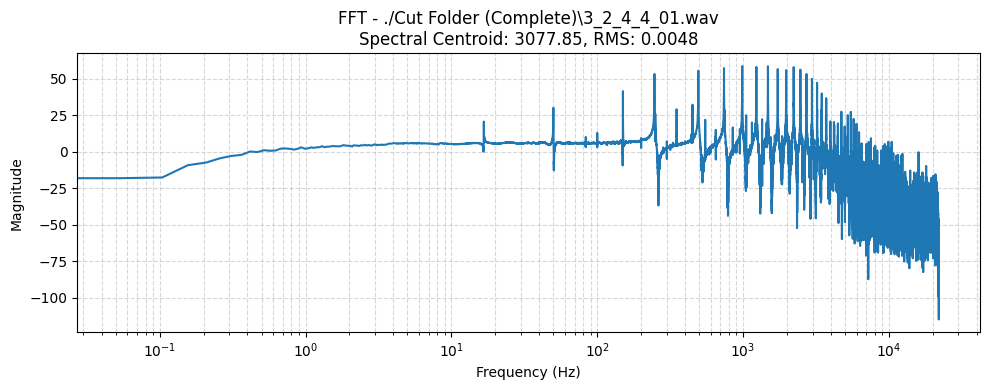

Ja geilo, löppt doch alles
So, fasst Ende jetzt
./Cut Folder (Complete)\3_2_4_4_01.wav  |  m=3  s=2  DL=4  y=4  x=1   sc=3077.850483571363    rms=0.0047706118784844875
Jetzt hamwa alles


In [16]:
# Beispiel um mir selbst zu zeigen, dass eine Berechnung des gefilterten Datensets funktioniert.

import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

def analyze_samples(samples):
    """
    Berechnet FFT, RMS und Spectral Centroid für eine Liste von Sample-Objekten.
    Fügt die Werte als Attribute in die Dataclass hinzu.
    Zeigt die FFT als Plot an.
    """
    for s in samples:
        # 1️⃣ Audio laden
        y, sr = librosa.load(s.filepath, sr=None)
        print("Yup")

        # 2️⃣ FFT berechnen
        fft = np.fft.rfft(y)          # nur positive Frequenzen
        fft_log = 20 * np.log10(np.abs(fft) + 1e-12)        # Log Frequenzen
        fft_mag = np.abs(fft)                                    # Magnitude
        fft_freqs = np.fft.rfftfreq(len(y), d=1/sr)
        print("Ham wa")

        # Attribute speichern
        s.fft_freqs = fft_freqs
        s.fft_mag = fft_mag
        print("Dat funzt auch")

        # 3️⃣ Spectral Centroid
        spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr).mean()
        s.spectral_centroid = spectral_centroid
        print("Schauma geht doch")

        # 4️⃣ RMS-Loudness
        rms = librosa.feature.rms(y=y).mean()
        s.rms = rms
        print("Siehste dit?")

        # 5️⃣ FFT plotten
        plt.figure(figsize=(10,4))
        plt.semilogx(fft_freqs, fft_log)
        plt.title(f"FFT - {s.filepath}\nSpectral Centroid: {spectral_centroid:.2f}, RMS: {rms:.4f}")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Magnitude")
        plt.grid(True, which="both", linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()
        print("Ja geilo, löppt doch alles")

analyze_samples(filtered)

print("So, fasst Ende jetzt")
for s in filtered:
        print(f"{s.filepath}  |  m={s.messung}  s={s.saite}  DL={s.durchlauf}  y={s.arrayy}  x={s.arrayx}   sc={s.spectral_centroid}    rms={s.rms}")

print("Jetzt hamwa alles")

In [36]:
# Lade wav-Dateien in Array-Form

import numpy as np
import soundfile as sf
from dataclasses import dataclass
# import plotly.graph_objects as go

# ------------------------------------------------------------
# 1) filtered enthält Dataclasses der Form:
#
# @dataclass
# class Sample:
#     filepath: str
#     messung: int
#     saite: int
#     durchlauf: int
#     arrayy: int  # 0..2   (3 Zeilen)
#     arrayx: int  # 0..10  (11 Spalten)
# ------------------------------------------------------------

# ------------------------------------------------------------
# WAV-Daten in ein (T, 3, 11)-Array laden
# ------------------------------------------------------------

def load_wav_matrix(filtered):
    """
    Lädt alle WAV-Dateien aus 'filtered' und ordnet sie nach (arrayy, arrayx).
    Gibt ein Array der Form (T, 3, 11) zurück.
    """
    # Sortieren, damit (0,0) bis (2,10) in korrekter Reihenfolge liegen
    filtered_sorted = sorted(filtered, key=lambda s: (s.arrayy, s.arrayx))

    # WAV-Dateien laden
    wavs = []
    lengths = []

    for sample in filtered_sorted:
        data, sr = sf.read(sample.filepath)     # data.shape = (T,) oder (T,Channels)
        if data.ndim > 1:
            data = data[:, 0]                   # Falls Stereo → auf Mono reduzieren
        wavs.append(data)
        lengths.append(len(data))

    # Alle WAVs auf gleiche Länge kürzen
    T = min(lengths)
    wavs = [w[:T] for w in wavs]

    # In Array bringen: (33, T)
    wav_matrix = np.vstack(wavs)  # shape: (33, T)

    # Reshape nach (T, 3, 11)
    data = wav_matrix.reshape(3, 11, T).transpose(2,0,1)

    return data, sr, T

def create_metadata(filtered, sr, T):
    """
    Creates Dictonary mith metadata to safe alongside array_data
    """
    meta = {
        "sr": sr,
        "T": T,
        "messung": filtered[1].messung,
        "saite": filtered[1].saite,
        "durchlauf": filtered[1].durchlauf,
        "type": "wav"
    }
    return meta

# ------------------------------------------------------------
# 3) Ausführen
# ------------------------------------------------------------

data_array, sr, T = load_wav_matrix(filtered)
meta = create_metadata(filtered,sr,T)

print("Loaded new wav-Array")
print(f"Metadaten: {meta}")


Loaded new wav-Array
Metadaten: {'sr': 44100, 'T': 655798, 'messung': 5, 'saite': 6, 'durchlauf': 5, 'type': 'wav'}


In [128]:
# RMS-Array erstellen

import numpy as np

def compute_rms_envelopes(data, sr, frame_length=1024, hop_length=None):
    """
    Berechnet RMS-Hüllkurven für ALLE Mikrofone im Array.
    
    Parameter:
        data : ndarray (T, 3, 11)
            Zeitliche Rohdaten aller Mikrofone.
        sr : int
            Samplerate.
        frame_length : int
            Fensterlänge für RMS-Berechnung.
        hop_length : int oder None
            Schrittweite zwischen den Fenstern.
            Falls None → hop_length = frame_length // 2 (50 % Overlap)

    Rückgabe:
        data_rms : ndarray (T_rms, 3, 11)
            RMS-Hüllkurvendaten in derselben Struktur wie das Original.
        sr_rms : float
            Effektive "Samplerate" der RMS-Hüllkurven (Frames pro Sekunde).
        T_rms : int
            Anzahl erzeugter Frames.
    """

    if hop_length is None:
        hop_length = frame_length // 2

    T, rows, cols = data.shape

    # Anzahl Frames berechnen
    T_rms = 1 + (T - frame_length) // hop_length
    if T_rms <= 0:
        raise ValueError("Frame length longer than signal")

    # Output-Array erzeugen
    data_rms = np.zeros((T_rms, rows, cols), dtype=float)

    # Für jedes Mikrofon getrennt RMS berechnen
    for y in range(rows):
        for x in range(cols):
            signal = data[:, y, x]

            rms_values = []
            for start in range(0, T - frame_length + 1, hop_length):
                frame = signal[start:start + frame_length]
                rms = np.sqrt(np.mean(frame**2))
                rms_values.append(rms)

            data_rms[:, y, x] = rms_values

    # "Samplerate" der neuen Zeitachse: Frames pro Sekunde
    sr_rms = sr / hop_length

    return data_rms, sr_rms, T_rms


# ------------------------------------------------------------
# Beispiel-Aufruf in Jupyter Notebook:
# ------------------------------------------------------------

# Angenommen:
# data  : dein ursprüngliches Array (T, 3, 11)
# sr    : Samplerate der WAVs

data_array, sr_rms, T_rms = compute_rms_envelopes(
    data_array,
    sr,
    frame_length=2048,  # beliebig einstellbar
    hop_length=1024     # optional, sonst 50% overlap
)

meta["type"]="rms"

print("RMS-Daten:", data_array.shape)
print("Neue effektive Samplerate:", sr_rms, "Frames/s")
print("Frames:", T_rms)


RMS-Daten: (1060, 3, 11)
Neue effektive Samplerate: 43.06640625 Frames/s
Frames: 1060


In [6]:
# Array-Animation mit t-Slider

import plotly.graph_objects as go

# ------------------------------------------------------------
# 2) Plotly-Animation erzeugen
# ------------------------------------------------------------

def create_heatmap_animation(data, t_start=0, t_end=None, step=100, playspeed=0):
    """
    Erzeugt eine animierte Heatmap über die Zeit.
    data: ndarray (T, 3, 11)
    """

    T, rows, cols = data.shape

    if t_end is None:
        t_end = T

    # Grenzen korrigieren
    t_start = max(0, t_start)
    t_end   = min(T, t_end)

    # Frames erzeugen
    frames = []
    for t in range(t_start, t_end, step):
        frames.append(
            go.Frame(
                data=[
                    go.Heatmap(
                        z=data[t],
                        zmin=data.min(),
                        zmax=data.max(),
                        colorscale="RdBu",
                        reversescale=True
                    )
                ],
                name=str(t)
            )
        )

    # Initiales Frame
    initial_t = t_start

    fig = go.Figure(
        data=[
            go.Heatmap(
                z=data[initial_t],
                zmin=data.min(),
                zmax=data.max(),
                colorscale="RdBu",
                reversescale=True
            )
        ],
        layout=go.Layout(
            title=f"Schallfeld im Mikrofonarray (Samples {t_start} – {t_end})",
            updatemenus=[
                {
                    "type": "buttons",
                    "buttons": [
                        {
                            "label": "Play",
                            "method": "animate",
                            "args": [
                                None,
                                {"frame": {"duration": playspeed}, "mode": "immediate"}
                            ]
                        }
                    ]
                }
            ],
            sliders=[
                {
                    "steps": [
                        {
                            "label": f"{t}",
                            "method": "animate",
                            "args": [
                                [str(t)],
                                {"mode": "immediate", "frame": {"duration": 0}}
                            ]
                        }
                        for t in range(t_start, t_end, step)
                    ],
                    "active": 0
                }
            ]
        ),
        frames=frames
    )

    fig.show()

# ------------------------------------------------------------
# 3) Ausführen
# ------------------------------------------------------------

create_heatmap_animation(
    data_array,
    # t_start=4500,
    # t_end=50000,
    step=1000,
    playspeed=50
)

In [129]:
# Arraydaten als Datensatz mit Metadaten speichern

import numpy as np
import json

np.savez(f"dataset_{meta["messung"]}_{meta["saite"]}_{meta["durchlauf"]}_{meta["type"]}", data=data_array, meta=np.array(json.dumps(meta)))

In [ ]:
# Arraydaten aus Datensatz mit Metadaten laden

import numpy as np
import json

npz = np.load("dataset_5_2_4_rms.npz", allow_pickle=True)
data_array_1 = npz["data"]
meta_1 = json.loads(npz["meta"].item())

In [141]:
# Mehrere Arraydaten aus Datensatz mit Metadaten laden

import numpy as np
import json

def export_picker(mode=1, a=1, b=1, c=6, suffix="rms", a_2=2):

    # 3 Modi 1,2 und 5.
    # 1 Exportiert einfach ein durch a,b,c und suffix spezifiziertes Sample mit Metadaten
    # 2 Exportiert zwei aus unterschiedlichen Messreihen mit sonst gleichem Aufbau
    # 5 iteriert über 5 Durchläufe, alle anderen Parameter sind fest
    # Daten werden in einem Dictionary gespeichert mit data_array_{i} und meta_{i}

    def export_one(a, b, c, suffix):
        file = [f"dataset_{a}_{b}_{c}_{suffix}.npz"]
        return file

    def export_two(a, a_2, b, c, suffix):
        files = []
        file_1 = f"dataset_{a}_{b}_{c}_{suffix}.npz"
        file_2 = f"dataset_{a_2}_{b}_{c}_{suffix}.npz"
        files.extend([file_1, file_2])
        return files

    def export_five(a, b, suffix):
        c=1
        files = []
        while c <= 5:
            file = f"dataset_{a}_{b}_{c}_{suffix}.npz"
            c += 1
            files.append(file)
        return files
    
    if mode == 1:
        files = export_one(a,b,c,suffix)
    elif mode == 2:
        files = export_two(a, a_2, b,c,suffix)
    elif mode == 5:
        files = export_five(a,b,suffix)
    else:
        print(f"No such mode as {mode}")
        files = []
    
    # Lädt die Daten der generierten Filenames in ein Dictionary

    results ={}

    for i, file in enumerate(files, start=1):
        npz = np.load(file, allow_pickle=True)
        data = npz["data"]
        meta = json.loads(npz["meta"].item())

        results[f"data_array_{i}"] = data
        results[f"meta_{i}"] = meta

    return results

# Speichert Dictionary als bulk_load
# Abrufen über Key z.B. bulk_load["meta_1"]

bulk_load = export_picker(c=1)

# Auflistung aller generierten meta Keys

i=1
while i <= round(len(bulk_load)/2):
    print(bulk_load[f"meta_{i}"])
    i += 1

{'sr': 44100, 'T': 728874, 'messung': 1, 'saite': 1, 'durchlauf': 1, 'type': 'rms'}


In [2]:
# Onset detection über librosa

import librosa

def onset_list(samples):

    onsets = {}
    for s in samples:
        # load sample
        y, sr = librosa.load(s.filepath, sr=None)

        # onset detection
        onset = librosa.onset.onset_detect(y=y, sr=sr, units="samples")
        # print(onset, f"{s.messung}_{s.saite}_{s.durchlauf}")
        
        for counter, o in enumerate(onset, start = 1):
            if int(o) <=10000:
                onsets[f"onset_{s.messung}_{s.saite}_{s.durchlauf}_{counter}"] = int(o)
                if counter >= 2:
                    print(f"Warning! {s.messung}_{s.saite}_{s.durchlauf}")
                else:
                        pass
            else:
                pass
    return onsets

onsets = onset_list(filtered)

print(onsets)


Warning! 8_3_2
{'onset_5_1_1_1': 4096, 'onset_5_1_2_1': 6144, 'onset_5_1_3_1': 4608, 'onset_5_1_4_1': 4096, 'onset_5_1_5_1': 5632, 'onset_5_2_1_1': 2560, 'onset_5_2_2_1': 2560, 'onset_5_2_3_1': 4096, 'onset_5_2_4_1': 4608, 'onset_5_2_5_1': 3072, 'onset_5_3_1_1': 3584, 'onset_5_3_2_1': 3072, 'onset_5_3_3_1': 4096, 'onset_5_3_4_1': 3584, 'onset_5_3_5_1': 3072, 'onset_5_4_1_1': 3584, 'onset_5_4_2_1': 4608, 'onset_5_4_3_1': 5632, 'onset_5_4_4_1': 2560, 'onset_5_4_5_1': 2560, 'onset_5_5_1_1': 4608, 'onset_5_5_2_1': 3072, 'onset_5_5_3_1': 3584, 'onset_5_5_4_1': 4608, 'onset_5_5_5_1': 4608, 'onset_5_6_1_1': 3072, 'onset_5_6_2_1': 2048, 'onset_5_6_3_1': 5632, 'onset_5_6_4_1': 4096, 'onset_5_6_5_1': 3072, 'onset_6_1_1_1': 4608, 'onset_6_1_2_1': 6144, 'onset_6_1_3_1': 5120, 'onset_6_1_4_1': 5632, 'onset_6_1_5_1': 4608, 'onset_6_2_1_1': 1536, 'onset_6_2_2_1': 3072, 'onset_6_2_3_1': 4096, 'onset_6_2_4_1': 4608, 'onset_6_2_5_1': 6144, 'onset_6_3_1_1': 2048, 'onset_6_3_2_1': 4096, 'onset_6_3_3_1': 3

In [4]:
# ab onset abspielen

import librosa
import plotly.graph_objects as go
import sounddevice as sd
import numpy as np
from scipy.signal import kaiserord, firwin, filtfilt, cheby2

'''
Filter-Design 1
'''
# cutoff = 10 # Hz

# # Filter length (länger heißt bessere Phase)
# numtaps = 513

# a = [1.0]

# # Erzeuge den Highpass-Filter
# high_pass = firwin(numtaps=numtaps, cutoff=cutoff, pass_zero=False, fs=sr)

'''
Filter-Design 2
'''
# cutoff = 10                 # Hz            

# transition_width = 200     # Wie schnell die Flanke ist

# ripple_db = 80              # Stopbanddämpfung in dB

# sr = 44100

# a = [1.0]

# nyq = sr/2
# width = transition_width / nyq

# # Bestimme Ordnung und Kaiser-beta
# N, beta = kaiserord(ripple_db, width)

# # Am besten mit ungerader Anzahl an Taps
# if N % 2 ==0:
#     N += 1

# print(f"numtaps={N}, beta={beta}")

# high_pass = firwin(numtaps=N, cutoff=cutoff, window=("kaiser", beta), pass_zero=False, fs=sr)

'''
Filter-Design 3
'''

order = 4
stopband_db = 120
cutoff = 10
sr = 44100
nyq = sr/2

high_pass, a = cheby2(order, stopband_db, cutoff/nyq, btype="highpass", analog=False)

'''
Filter-Design 4
'''

# plot filtered and aligned files

for o,f in zip(onsets,filtered):
    # print(o)
    # print(f.filepath)

    y, sr = librosa.load(f.filepath, sr=None)

    # Linear-Phase Filter gegen aufgezeichnete Luftdruckschwankungen im Raum
    y = filtfilt(high_pass, a, y)

    onset = onsets[o] - 1024

    audio_offset = y[onset:sr + onset]
    # audio_offset = y[:sr]
    time = np.arange(len(audio_offset)) / sr

    print(y)

    # fig = go.Figure()
    # fig.add_trace(go.Scatter(x=time, y=audio_offset, mode="lines"))
    # fig.update_layout(
    #     title=f"Waveform {o} ab {round(onset*10000/sr)/10000} s",
    #     xaxis_title="Zeit (s)",
    #     yaxis_title="Amplitude",
    # )
    # fig.show()

# sd.play(y[onset:], sr)
# sd.wait()


[ 1.56978076e-08  1.94367323e-08  2.32396734e-08 ...  1.55414965e-07
  6.10141430e-07 -1.25772285e-07]
[-4.81161430e-08  7.62396526e-08 -3.78099993e-08 ...  2.75499376e-06
  5.05931575e-06  9.77203123e-08]
[ 8.00903094e-08  8.29405935e-08  8.58250742e-08 ... -5.51911399e-08
 -2.79426674e-08 -2.33862297e-10]
[-5.61219341e-08 -5.90571676e-08 -6.20485889e-08 ... -3.47779448e-08
  4.87242907e-09  4.42321026e-08]
[ 7.40830077e-07  1.28457259e-06  7.56230741e-07 ...  3.06314686e-08
 -5.77589065e-09 -4.21849835e-08]
[-4.00969840e-08 -2.88599808e-07 -2.98858638e-07 ... -9.87178605e-08
 -2.04250265e-07  4.77518184e-08]
[ 3.96583212e-07  1.03834926e-06  7.27173107e-07 ... -2.25174420e-07
 -5.52203218e-07  7.32369636e-08]
[-1.46761222e-07 -2.76959866e-07 -1.68922786e-07 ...  4.96488824e-08
  3.34038406e-07  2.23939113e-08]
[-4.63072738e-08 -5.10789854e-08 -5.59015377e-08 ...  7.60797137e-08
  2.05015529e-08 -3.48165807e-08]
[ 5.49189163e-07  1.07863458e-06  5.35921915e-07 ... -4.60702639e-07
 -8.

In [ ]:
# Onsets speichern

import json

with open("onsets.json", "w") as f:
    json.dump(onsets, f)

In [2]:
# Onsets laden

import json

with open("onsets.json", "r") as f:
    onsets = json.load(f)

print(onsets["onset_8_1_2_1"])

4608


In [3]:
first_onset = min(onsets, key=onsets.get)
print(first_onset)
print(onsets[f"{first_onset}"])

onset_6_2_1_1
1536


In [37]:
# Finalize the Array form
# Cut, apply High Pass filter, apply fade in / out to array

import numpy as np
from scipy.signal import filtfilt, cheby2
from pathlib import Path
import json

# General Parameters

# Cutting Parameters
audio_length = 3       # in seconds

# Windowing Parameters
fade_time = 0.01       # in seconds

# Filter Parameters
order = 4
stopband_db = 120
cutoff = 10

# Function to apply it all

def finalize_array(data, meta, onsets):

    # Generelle Infos herausziehen
    sr = meta["sr"]
    nyq = sr/2

    T, rows, cols = data.shape

    # Anzahl der Frames berechnen
    T_final = audio_length * sr

    # Output-Array erzeugen
    data_final = np.zeros((T_final, rows, cols), dtype=float)

    # Filter definieren
    highpass, a = cheby2(order, stopband_db, cutoff/nyq, btype="highpass", analog=False)

    # Fade Länge berechnen
    T_fade = int(fade_time * sr)

    # Offset finden
    T_start = onsets[f"onset_{meta["messung"]}_{meta["saite"]}_{meta["durchlauf"]}_1"] - 2 * T_fade
    T_end = T_start + audio_length * sr

    # Fades definieren
    fade_in = np.hanning(2*T_fade)[:T_fade]
    fade_out = np.hanning(2*T_fade)[T_fade:]
    

    # Für jedes Mikrofon individuelle Berechnung
    for y in range(rows):
        for x in range(cols):
            signal = data[:, y, x]

            # filter signal (linear phase)
            signal = filtfilt(highpass, a, signal)

            # cut signal with onset data
            signal = signal[T_start:T_end]

            # apply window functions
            signal[:T_fade] *= fade_in
            signal[-T_fade:] *= fade_out

            # plot to be very shure?

            data_final[:,y,x] = signal

    return data_final # , T_final, sr_final

# Funktion callen
data_array = finalize_array(data_array, meta, onsets)

# Type parameter ändern
meta["type"] = "fwav"

# Als .npz speichern
out_dir = Path("Finalized Arrays")      # relativer Ordner
out_dir.mkdir(parents=True, exist_ok=True)

filename = (f"dataset_{meta["messung"]}_{meta["saite"]}_{meta["durchlauf"]}_{meta["type"]}.npz")

out_path = out_dir / filename

np.savez(out_path, data = data_array, meta = np.array(json.dumps(meta)))

print(f"Saved {filename} to {out_dir}")

Saved dataset_5_6_5_fwav.npz to Finalized Arrays


In [25]:
# Schnell Daten plotten

import plotly.express as px
import numpy as np

y = data_array[:,1,1]

t = np.linspace(0,len(y)/44100,len(y))

fig = px.line(x=t, y=y, labels={"x": "Zeit", "y": "Amplitude"})
fig.show()


In [ ]:
# Automatisches Abspeichern eines kompletten Datasets

folder = r"./Cut Folder (Complete)"    # <--- Anpassen!

all_samples = load_samples(folder)

for m in range(5,9):
    for s in range(1,7):
        for d in range(1,6):
            # Liste filtern
            filtered = filter_samples_range(all_samples, arrayy=(1,3), saite = s, messung = m, durchlauf = d)

            # Array kreieren
            data_array, sr, T = load_wav_matrix(filtered)
            # Metadaten verfassen
            meta = create_metadata(filtered,sr,T)